# Born Displaced — Data Cleaning & Integration
**Datasets**: UNICEF child mortality · UNHCR displacement · World Bank macro  
**Period**: 2010–2022

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='muted')

## 1. Load raw datasets

In [2]:
unicef_1t4  = pd.read_csv('fusion_GLOBAL_DATAFLOW_UNICEF_1.0_.CME_MRY1T4..csv')
unicef_5t14 = pd.read_csv('fusion_GLOBAL_DATAFLOW_UNICEF_1.0_.CME_MRY5T14..csv')
unhcr       = pd.read_csv('population.csv')
wb          = pd.read_csv('worldbank_macro.csv')

print('UNICEF 1-4:  ', unicef_1t4.shape)
print('UNICEF 5-14: ', unicef_5t14.shape)
print('UNHCR:       ', unhcr.shape)
print('World Bank:  ', wb.shape)

UNICEF 1-4:   (9711, 22)
UNICEF 5-14:  (9711, 22)
UNHCR:        (64809, 16)
World Bank:   (3458, 6)


## 2. Clean UNICEF mortality data

In [3]:
def clean_unicef(df, rate_col_name):
    # parse country ISO code from 'AFG: Afghanistan' format
    df['country_iso'] = df['REF_AREA:Geographic area'].str.extract(r'^([A-Z]+):')
    df['country_name'] = df['REF_AREA:Geographic area'].str.extract(r': (.+)$')

    # keep only total sex, normal values
    df = df[
        (df['SEX:Sex'] == '_T: Total') &
        (df['OBS_STATUS:Observation Status'] == 'A: Normal value')
    ].copy()

    df = df.rename(columns={
        'TIME_PERIOD:Time period': 'year',
        'OBS_VALUE:Observation Value': rate_col_name,
        'LOWER_BOUND:Lower Bound': f'{rate_col_name}_low',
        'UPPER_BOUND:Upper Bound': f'{rate_col_name}_high',
    })

    return df[['country_iso', 'country_name', 'year',
               rate_col_name, f'{rate_col_name}_low', f'{rate_col_name}_high']].copy()

u1t4  = clean_unicef(unicef_1t4,  'mortality_1t4')
u5t14 = clean_unicef(unicef_5t14, 'mortality_5t14')

unicef = u1t4.merge(u5t14, on=['country_iso', 'country_name', 'year'], how='outer')
print(unicef.shape)
unicef.head()

(3159, 9)


,country_iso,country_name,year,mortality_1t4,mortality_1t4_low,mortality_1t4_high,mortality_5t14,mortality_5t14_low,mortality_5t14_high
0,AFG,Afghanistan,2010,11.956196,10.870064,13.106192,9.219909,7.550709,11.609253
1,AFG,Afghanistan,2011,11.145113,10.070603,12.265982,8.803292,7.265068,10.789937
2,AFG,Afghanistan,2012,10.380682,9.328987,11.494221,8.275966,6.866598,9.962940
3,AFG,Afghanistan,2013,9.673693,8.638934,10.785972,8.575657,7.042711,10.388708
4,AFG,Afghanistan,2014,9.037536,8.022762,10.160109,8.587264,6.791851,10.709411


## 3. Clean UNHCR displacement data

In [4]:
# replace 'NA' strings with actual NaN
unhcr = unhcr.replace('NA', np.nan)

disp_cols = ['refugees', 'asylum_seekers', 'idps']
for col in disp_cols:
    unhcr[col] = pd.to_numeric(unhcr[col], errors='coerce').fillna(0)

# aggregate by country of ORIGIN + year
# (how many people fled FROM each country)
origin = (
    unhcr.groupby(['coo_iso', 'year'], as_index=False)
    .agg(
        refugees_origin      = ('refugees',       'sum'),
        asylum_seekers_origin= ('asylum_seekers', 'sum'),
        idps                 = ('idps',           'sum'),
    )
    .rename(columns={'coo_iso': 'country_iso'})
)

# aggregate by country of ASYLUM + year
# (how many people the country is hosting)
asylum = (
    unhcr.groupby(['coa_iso', 'year'], as_index=False)
    .agg(refugees_hosted=('refugees', 'sum'))
    .rename(columns={'coa_iso': 'country_iso'})
)

unhcr_clean = origin.merge(asylum, on=['country_iso', 'year'], how='left')
unhcr_clean['total_displaced'] = (
    unhcr_clean['refugees_origin'] +
    unhcr_clean['asylum_seekers_origin'] +
    unhcr_clean['idps']
)

print(unhcr_clean.shape)
unhcr_clean.head()

(2559, 7)


,country_iso,year,refugees_origin,asylum_seekers_origin,idps,refugees_hosted,total_displaced
0,ABW,2021,0,0,0,0.0,0
1,ABW,2022,0,7,0,0.0,7
2,AFG,2010,3054699,37101,351907,6434.0,3443707
3,AFG,2011,2664423,39199,447547,3011.0,3151169
4,AFG,2012,2586132,62304,486298,16184.0,3134734


## 4. Align country codes and integrate

In [5]:
# World Bank uses ISO3 codes — align with UNICEF/UNHCR codes
# known mismatches (WB code → ISO3)
WB_TO_ISO3 = {
    'XKX': 'XKX',  # Kosovo (non-standard)
    'PSE': 'PSE',  # Palestine
    'TLS': 'TLS',  # Timor-Leste
}

wb_clean = wb.rename(columns={'country_code': 'country_iso'})

# step 1: merge UNICEF + UNHCR
df = unicef.merge(unhcr_clean, on=['country_iso', 'year'], how='left')

# step 2: merge with World Bank
df = df.merge(
    wb_clean[['country_iso', 'year', 'gdp_per_capita', 'unemployment_rate', 'inflation_cpi']],
    on=['country_iso', 'year'],
    how='left'
)

# filter to 2010-2022 and drop aggregate regions
EXCLUDE = ['WLD','LIC','MIC','HIC','LMC','UMC','EAP','ECA','LAC','MNA','SAR','SSA','NAC',
           'EUU','EMU','ARB','CSS','EAR','ECS','FCS','HPC','IBD','IBT','IDA','IDB','IDX',
           'LDC','LTE','MIC','OED','OSS','PRE','PSS','PST','SST','TSA','TEA','TEC','TLA',
           'TMN','TSS']
df = df[
    df['year'].between(2010, 2022) &
    ~df['country_iso'].isin(EXCLUDE)
].reset_index(drop=True)

print('Master dataset:', df.shape)
df.head()

Master dataset: (3159, 17)


,country_iso,country_name,year,mortality_1t4,mortality_1t4_low,mortality_1t4_high,mortality_5t14,mortality_5t14_low,mortality_5t14_high,refugees_origin,asylum_seekers_origin,idps,refugees_hosted,total_displaced,gdp_per_capita,unemployment_rate,inflation_cpi
0,AFG,Afghanistan,2010,11.956196,10.870064,13.106192,9.219909,7.550709,11.609253,3054699.0,37101.0,351907.0,6434.0,3443707.0,560.621505,7.809,2.178538
1,AFG,Afghanistan,2011,11.145113,10.070603,12.265982,8.803292,7.265068,10.789937,2664423.0,39199.0,447547.0,3011.0,3151169.0,606.694676,7.830,11.804186
2,AFG,Afghanistan,2012,10.380682,9.328987,11.494221,8.275966,6.866598,9.962940,2586132.0,62304.0,486298.0,16184.0,3134734.0,651.417134,7.875,6.441213
3,AFG,Afghanistan,2013,9.673693,8.638934,10.785972,8.575657,7.042711,10.388708,2556483.0,75284.0,631286.0,16861.0,3263053.0,637.087099,7.921,7.385772
4,AFG,Afghanistan,2014,9.037536,8.022762,10.160109,8.587264,6.791851,10.709411,2596259.0,85407.0,805409.0,300421.0,3487075.0,625.054942,7.915,4.673996


## 5. Missing value analysis

                       missing   pct
refugees_hosted           1020  32.3
unemployment_rate          833  26.4
inflation_cpi              813  25.7
asylum_seekers_origin      723  22.9
refugees_origin            723  22.9
idps                       723  22.9
total_displaced            723  22.9
gdp_per_capita             661  20.9
country_iso                546  17.3
mortality_5t14_high          0   0.0
mortality_5t14_low           0   0.0
mortality_5t14               0   0.0
mortality_1t4_high           0   0.0
mortality_1t4_low            0   0.0
mortality_1t4                0   0.0
year                         0   0.0
country_name                 0   0.0


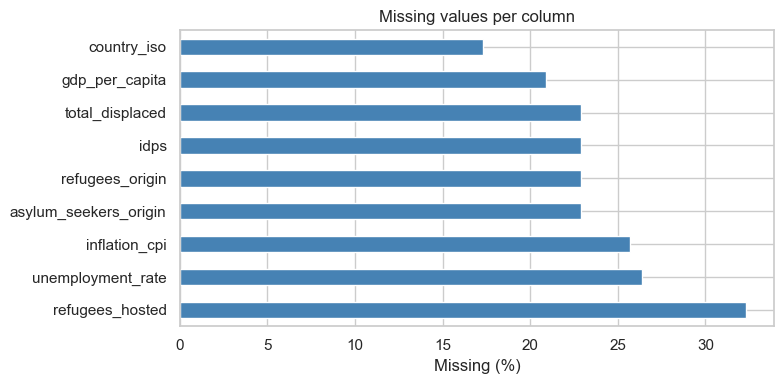

In [6]:
missing = df.isna().sum().sort_values(ascending=False)
pct     = (missing / len(df) * 100).round(1)
print(pd.DataFrame({'missing': missing, 'pct': pct}).to_string())

fig, ax = plt.subplots(figsize=(8, 4))
pct[pct > 0].plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Missing (%)')
ax.set_title('Missing values per column')
plt.tight_layout()
plt.savefig('missing_values.png', dpi=120)
plt.show()

## 6. Exploratory Analysis

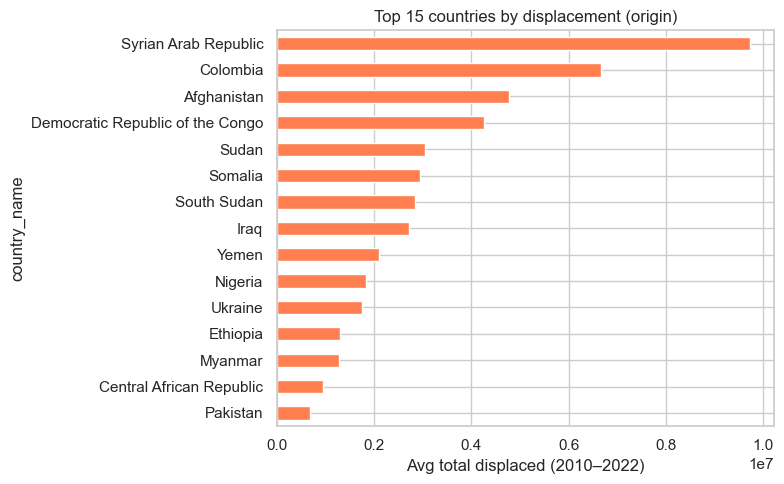

In [7]:
# countries with highest total displacement (avg 2010-2022)
top_displaced = (
    df.groupby('country_name')['total_displaced']
    .mean()
    .dropna()
    .sort_values(ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(8, 5))
top_displaced.plot(kind='barh', ax=ax, color='coral')
ax.set_xlabel('Avg total displaced (2010–2022)')
ax.set_title('Top 15 countries by displacement (origin)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('top_displaced.png', dpi=120)
plt.show()

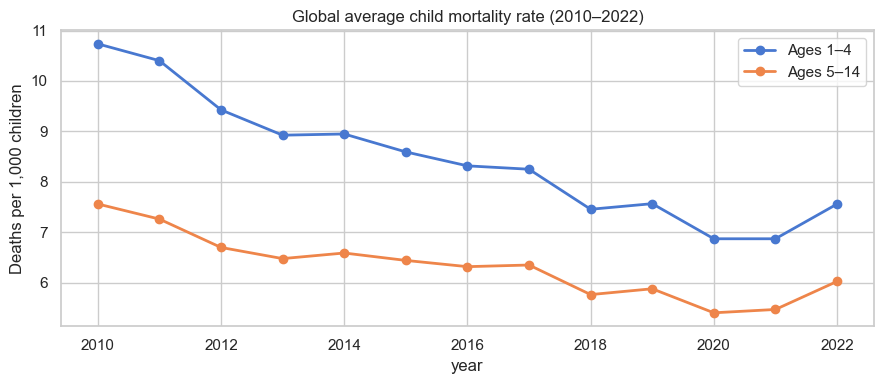

In [8]:
# global trend: avg child mortality over time
trend = df.groupby('year')[['mortality_1t4', 'mortality_5t14']].mean()

fig, ax = plt.subplots(figsize=(9, 4))
trend.plot(ax=ax, marker='o', linewidth=2)
ax.set_title('Global average child mortality rate (2010–2022)')
ax.set_ylabel('Deaths per 1,000 children')
ax.legend(['Ages 1–4', 'Ages 5–14'])
plt.tight_layout()
plt.savefig('mortality_trend.png', dpi=120)
plt.show()

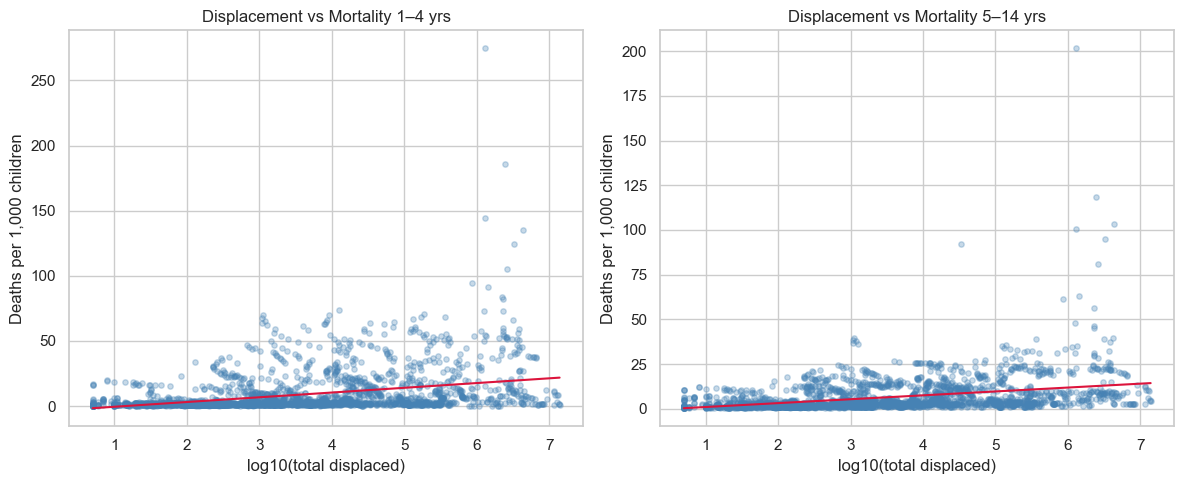

In [9]:
# displacement vs child mortality scatter (log scale)
plot_df = df[
    df['total_displaced'].notna() &
    df['mortality_1t4'].notna() &
    (df['total_displaced'] > 0)
].copy()
plot_df['log_displaced'] = np.log10(plot_df['total_displaced'])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, mort_col, title in zip(
    axes,
    ['mortality_1t4', 'mortality_5t14'],
    ['Mortality 1–4 yrs', 'Mortality 5–14 yrs']
):
    ax.scatter(plot_df['log_displaced'], plot_df[mort_col],
               alpha=0.3, s=15, color='steelblue')
    m, b = np.polyfit(plot_df['log_displaced'], plot_df[mort_col].fillna(0), 1)
    x_line = np.linspace(plot_df['log_displaced'].min(), plot_df['log_displaced'].max(), 100)
    ax.plot(x_line, m * x_line + b, color='crimson', linewidth=1.5)
    ax.set_xlabel('log10(total displaced)')
    ax.set_ylabel('Deaths per 1,000 children')
    ax.set_title(f'Displacement vs {title}')

plt.tight_layout()
plt.savefig('scatter_displacement_mortality.png', dpi=120)
plt.show()

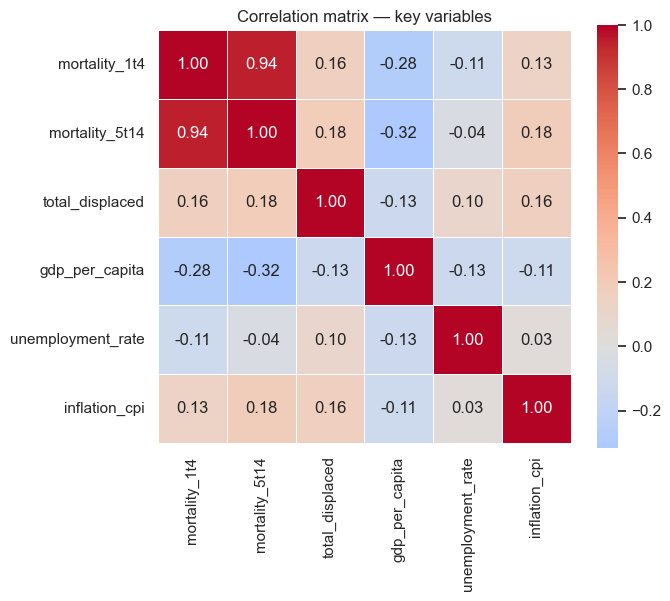

In [10]:
# correlation heatmap of key variables
corr_cols = ['mortality_1t4', 'mortality_5t14', 'total_displaced',
             'gdp_per_capita', 'unemployment_rate', 'inflation_cpi']
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, ax=ax, linewidths=0.5)
ax.set_title('Correlation matrix — key variables')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=120)
plt.show()

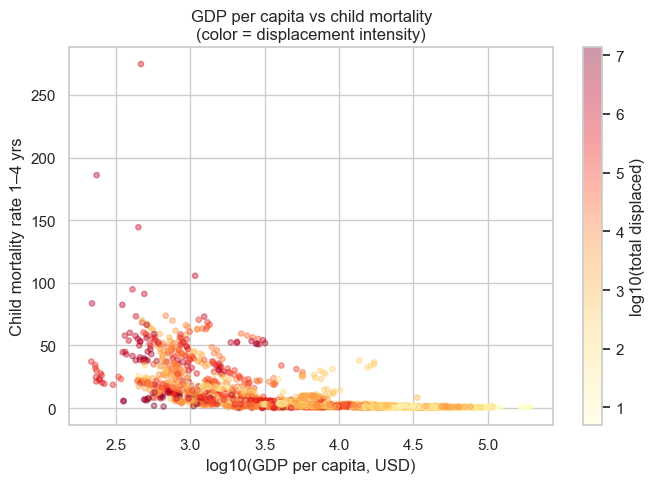

In [11]:
# GDP per capita vs mortality (macroeconomic mediation check)
plot_df2 = df[df['gdp_per_capita'].notna() & df['mortality_1t4'].notna()].copy()
plot_df2['log_gdp'] = np.log10(plot_df2['gdp_per_capita'])

fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(plot_df2['log_gdp'], plot_df2['mortality_1t4'],
                c=np.log10(plot_df2['total_displaced'].clip(1)),
                cmap='YlOrRd', alpha=0.4, s=15)
plt.colorbar(sc, ax=ax, label='log10(total displaced)')
ax.set_xlabel('log10(GDP per capita, USD)')
ax.set_ylabel('Child mortality rate 1–4 yrs')
ax.set_title('GDP per capita vs child mortality\n(color = displacement intensity)')
plt.tight_layout()
plt.savefig('gdp_mortality_displacement.png', dpi=120)
plt.show()

## 7. Save master dataset

In [12]:
df.to_csv('master_dataset.csv', index=False)
print(f'Saved master_dataset.csv — {df.shape[0]} rows, {df.shape[1]} columns')
print('Countries:', df['country_iso'].nunique())
print('Years:    ', sorted(df['year'].unique()))
df.dtypes

Saved master_dataset.csv — 3159 rows, 17 columns
Countries: 201
Years:     [np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)]


country_iso                  str
country_name                 str
year                       int64
mortality_1t4            float64
mortality_1t4_low        float64
mortality_1t4_high       float64
mortality_5t14           float64
mortality_5t14_low       float64
mortality_5t14_high      float64
refugees_origin          float64
asylum_seekers_origin    float64
idps                     float64
refugees_hosted          float64
total_displaced          float64
gdp_per_capita           float64
unemployment_rate        float64
inflation_cpi            float64
dtype: object